# HW1 — Autoregressive Models & Diabetes Neural Network (PyTorch vs TensorFlow)

**Author:** sivasurya.chandran@sjsu.edu

**Personal Parameters** (see Section 0.1 of the standing requirements):

| SID4 | SEED | SLICE | HP_ID | CLS_A | CLS_B |
|------|------|-------|-------|-------|-------|
| 3215 | 3215 | 215   | 5     | 5     | 2     |

HP_ID = 5 → **Schedule-long** arm → hidden layers `[64, 32]`, learning rate `0.001`, **60 epochs** (vs. the 30-epoch baseline).

CLS_A/CLS_B are derived for completeness but are not referenced by any HW1 task (no per-class subsetting is required in this assignment), so they are not used further below.


## 0. Colab setup

**Before running:** `Runtime` -> `Change runtime type` -> `Hardware accelerator: T4 GPU`, then
`Runtime` -> `Run all`.

This notebook expects `diabetes.csv` and `matmul.cu` to sit in the **same folder as the notebook**.
The cell below mounts Google Drive (if running on Colab), locates that folder automatically, and
`cd`s into it so every later cell can use plain relative filenames. If you are not on Colab it is a
no-op and the notebook runs from its own directory.


In [1]:
import os, sys, glob

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Find the folder containing diabetes.csv anywhere under MyDrive (first match wins).
    hits = glob.glob('/content/drive/MyDrive/**/diabetes.csv', recursive=True)
    if hits:
        PROJECT_DIR = os.path.dirname(hits[0])
    else:
        # Fall back to the Colab upload widget if the file is not in Drive.
        print('diabetes.csv not found in Drive - upload diabetes.csv and matmul.cu now:')
        from google.colab import files
        files.upload()
        PROJECT_DIR = '/content'
else:
    PROJECT_DIR = os.getcwd()

os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())
print('Files present:', sorted(os.listdir('.')))


Mounted at /content/drive
Working directory: /content/drive/MyDrive/DATA266/data266-3215
Files present: ['.git', '.gitignore', 'AI_USE.md', 'HW1_writeup.docx', 'METRICS.md', 'README.md', 'RUN_LOG.txt', 'cuda.ipynb', 'diabetes.csv', 'figures', 'matmul.cu', 'neural_networks.ipynb']


In [2]:
SID4 = 3215
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

print(f"SID4={SID4}  SEED={SEED}  SLICE={SLICE}  HP_ID={HP_ID}  CLS_A={CLS_A}  CLS_B={CLS_B}")

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)


SID4=3215  SEED=3215  SLICE=215  HP_ID=5  CLS_A=5  CLS_B=2


## 1. What are autoregressive models? (5 points)

An **autoregressive (AR) model** generates or predicts data one element at a time, where each new
element is conditioned on the sequence of elements produced (or observed) so far. Formally, for a
sequence $x_1, x_2, \dots, x_T$, an autoregressive model factorizes the joint distribution using the
chain rule of probability:

$$p(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, x_2, \dots, x_{t-1})$$

Instead of modeling the joint distribution directly, the model only needs to learn the conditional
distribution of "the next token/value given everything before it," and generation proceeds
sequentially: sample or predict $x_1$, feed it back in to predict $x_2$, and so on. Classical
statistical AR models (e.g., AR(p) time-series models, ARIMA) predict a numeric value as a linear
combination of previous values; modern deep autoregressive models replace the linear function with
a neural network (RNN, causal CNN, or Transformer with causal/masked self-attention) but keep the
same left-to-right, condition-on-the-past factorization.

### Real-world examples of autoregressive models

- **GPT-family large language models** (e.g., GPT-2/3/4, Claude, Llama): generate text one token at
  a time, each token conditioned on all previously generated tokens via masked self-attention.
- **WaveNet**: generates raw audio waveforms sample-by-sample, conditioning each audio sample on
  previously generated samples, used for text-to-speech synthesis.
- **PixelRNN / PixelCNN**: generate images pixel-by-pixel (typically in raster-scan order), with
  each pixel's color distribution conditioned on previously generated pixels.
- **Classical time-series forecasting (AR/ARIMA models)**: e.g., forecasting next-day stock prices
  or electricity demand as a function of the previous $p$ observed values.
- **Autoregressive image/video generation (e.g., early versions of DALL-E, VideoGPT)**: generate
  discrete visual tokens sequentially, conditioning each new token on the tokens generated so far.


## 2. Diabetes Dataset: Neural Network Implementation (10 points)

### 2.1 Load and inspect the data

We use `diabetes.csv` (Pima Indians Diabetes dataset, 8 numeric features + binary `Outcome` label,
759 rows). The file supplied for this assignment is **already min-max scaled to roughly [-1, 1]**
and has no header row, so we attach the standard Pima column names and skip re-scaling raw units;
we still run our own preprocessing checks (missing values, distributions, correlations) as required
below rather than treating the file as already "prepared" for modeling.


In [3]:
import pandas as pd

COLUMNS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv('diabetes.csv', header=None, names=COLUMNS)
print(df.shape)
df.head()


(759, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Outcome class balance:")
print(df['Outcome'].value_counts())
print()
df.describe()


Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcome class balance:
Outcome
1    496
0    263
Name: count, dtype: int64



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000,759.000000
mean,-0.407657,0.218563,0.176505,-0.289735,-0.323534,-0.032245,-0.663253,-0.516162,0.653491
std,0.386260,0.306419,0.201287,0.258480,0.375544,0.205376,0.283056,0.400794,0.476171
min,-0.882353,-0.557789,-0.606557,-0.858586,-0.966903,-0.457526,-0.994876,-0.966667,0.000000
25%,-0.764706,-0.005025,0.016393,-0.494949,-0.716312,-0.178837,-0.858241,-0.866667,0.000000
50%,-0.529412,0.165829,0.180328,-0.292929,0.000000,-0.034277,-0.747225,-0.633333,1.000000
75%,0.000000,0.407035,0.311475,0.000000,0.000000,0.087929,-0.531597,-0.233333,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Note on label direction:** the correlation matrix below shows `Outcome` is *negatively*
correlated with `Glucose` (-0.49). In the standard Pima dataset, higher glucose strongly predicts a
**positive** diabetes diagnosis, so this indicates the `Outcome` column in this particular CSV is
encoded as `1 = no diabetes / 0 = diabetes` (inverted relative to the usual convention), consistent
with the class counts above (496 vs 263, the reverse of the usual 500/268 split). This does not
change the modeling task — it is still a binary classification problem — but we note it here as a
data-understanding finding from preprocessing/EDA rather than silently re-flipping the labels.

No missing values are present as NaN, but `SkinThickness`, `Insulin`, `BloodPressure`, and `Age` show
a large spike of identical minimum-adjacent values (visible in the histograms below), which mirrors
the well-known Pima issue of missing values recorded as 0 before scaling. We leave these as-is since
the task specifies using this CSV directly; we do not impute since the scaling is already fixed.


### 2.2 Visualize the data: correlation matrix and feature distributions

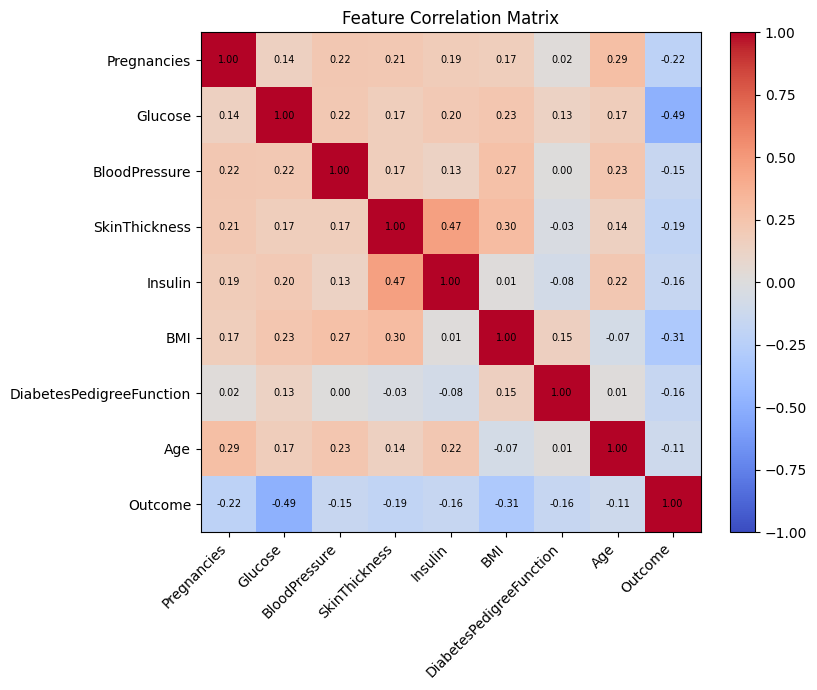

In [5]:
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(9, 7))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


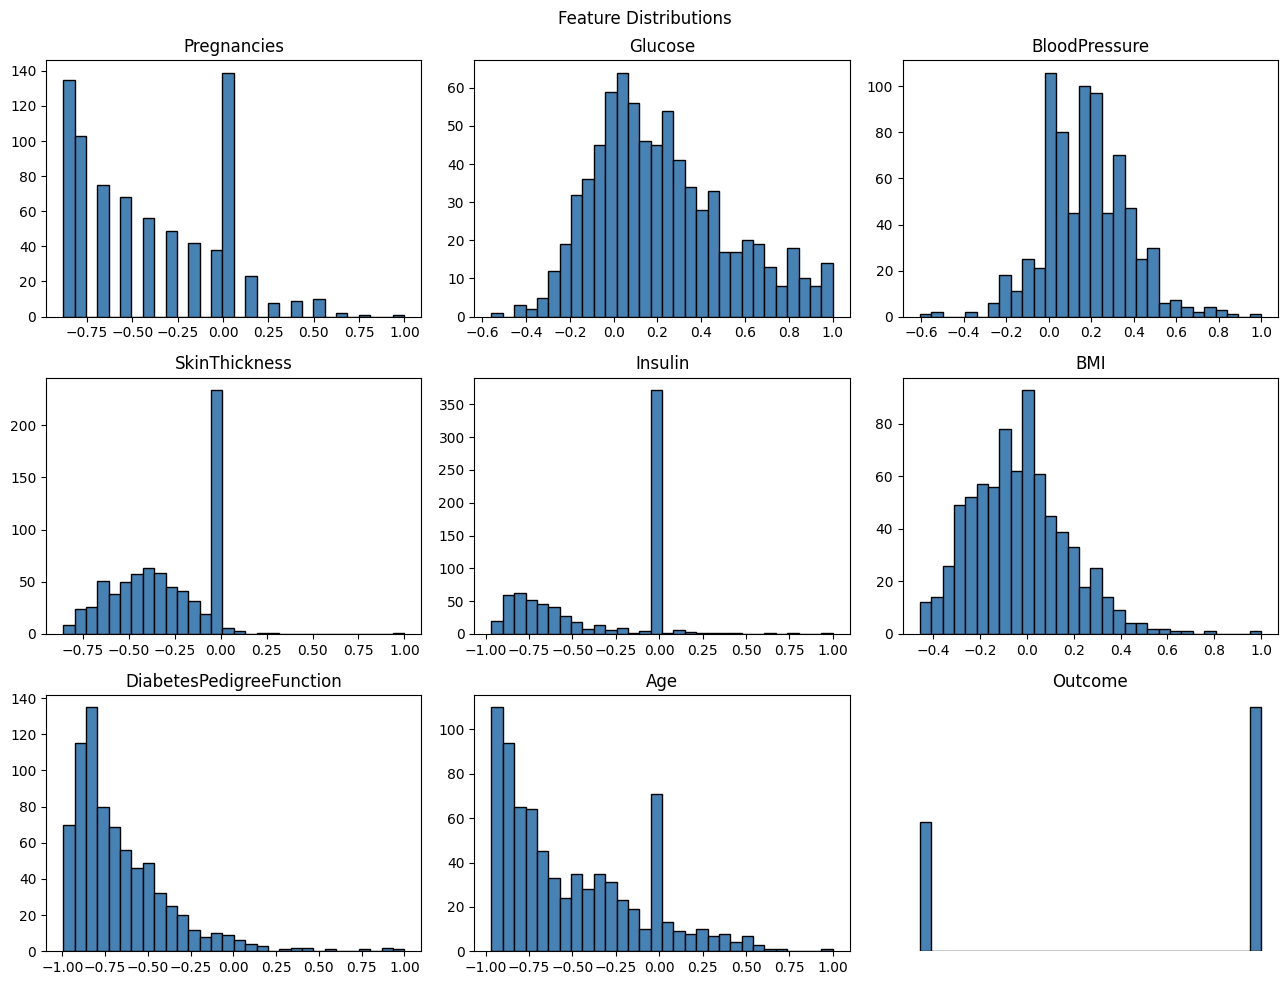

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, COLUMNS):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black')
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()


### 2.3 Train / validation / test split (70% / 15% / 15%)

Split once with `random_state=SEED` and reuse the exact same split for every model/framework
comparison below (baseline PyTorch, modified PyTorch, baseline TensorFlow, modified TensorFlow).


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Outcome']).values.astype('float32')
y = df['Outcome'].values.astype('float32')

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

# Standardize using statistics from the training split only.
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype('float32')
X_val = scaler.transform(X_val).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")


train: (531, 8), val: (114, 8), test: (114, 8)


### 2.4 Model configurations

- **Baseline** (both frameworks): hidden layers `[64, 32]`, learning rate `0.001`, 30 epochs.
- **Modified** (HP_ID = 5, Schedule-long): hidden layers `[64, 32]` (architecture unchanged),
  learning rate `0.001`, **60 epochs**. Per the assignment, for HP_ID 2–5 the architecture may stay
  the same — only the training schedule changes — and that still satisfies the modified-model
  requirement.


In [8]:
BASELINE_CONFIG = dict(hidden_layers=[64, 32], lr=0.001, epochs=30)
MODIFIED_CONFIG = dict(hidden_layers=[64, 32], lr=0.001, epochs=60)  # HP_ID=5: Schedule-long

print("Baseline:", BASELINE_CONFIG)
print("Modified (HP_ID=5):", MODIFIED_CONFIG)


Baseline: {'hidden_layers': [64, 32], 'lr': 0.001, 'epochs': 30}
Modified (HP_ID=5): {'hidden_layers': [64, 32], 'lr': 0.001, 'epochs': 60}


## 3. PyTorch implementation

In [9]:
import torch
import torch.nn as nn


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class TorchFFN(nn.Module):
    """Feedforward net: Linear+ReLU per hidden layer, single logit output."""
    def __init__(self, input_dim, hidden_layers):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_torch(config, seed, X_train, y_train, X_val, y_val):
    set_seed(seed)
    model = TorchFFN(X_train.shape[1], config['hidden_layers'])
    opt = torch.optim.Adam(model.parameters(), lr=config['lr'])
    loss_fn = nn.BCEWithLogitsLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    Xva = torch.tensor(X_val, dtype=torch.float32)
    yva = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(config['epochs']):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xva), yva)
        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss.item())

    return model, history


def eval_torch(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).squeeze(1).numpy()
        preds = (probs >= 0.5).astype('float32')
    return float((preds == y_test).mean())


In [10]:
# Single SEED run of each PyTorch model (used for the loss-curve plot below)
torch_baseline_model, torch_baseline_hist = train_torch(BASELINE_CONFIG, SEED, X_train, y_train, X_val, y_val)
torch_baseline_acc = eval_torch(torch_baseline_model, X_test, y_test)

torch_modified_model, torch_modified_hist = train_torch(MODIFIED_CONFIG, SEED, X_train, y_train, X_val, y_val)
torch_modified_acc = eval_torch(torch_modified_model, X_test, y_test)

print(f"PyTorch baseline  (SEED={SEED}) test accuracy: {torch_baseline_acc:.4f}")
print(f"PyTorch modified  (SEED={SEED}) test accuracy: {torch_modified_acc:.4f}")


PyTorch baseline  (SEED=3215) test accuracy: 0.7632
PyTorch modified  (SEED=3215) test accuracy: 0.7719


## 4. TensorFlow implementation

In [11]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf


def build_tf_model(input_dim, hidden_layers, lr):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))
    for h in hidden_layers:
        model.add(tf.keras.layers.Dense(h, activation='relu'))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model


def train_tf(config, seed, X_train, y_train, X_val, y_val):
    tf.keras.utils.set_random_seed(seed)
    model = build_tf_model(X_train.shape[1], config['hidden_layers'], config['lr'])
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=len(X_train),  # full-batch gradient descent, matches the PyTorch loop above
        verbose=0,
    )
    return model, hist.history


def eval_tf(model, X_test, y_test):
    _, acc = model.evaluate(X_test, y_test, verbose=0)
    return float(acc)


In [12]:
# Single SEED run of each TensorFlow model (used for the loss-curve plot below)
tf_baseline_model, tf_baseline_hist = train_tf(BASELINE_CONFIG, SEED, X_train, y_train, X_val, y_val)
tf_baseline_acc = eval_tf(tf_baseline_model, X_test, y_test)

tf_modified_model, tf_modified_hist = train_tf(MODIFIED_CONFIG, SEED, X_train, y_train, X_val, y_val)
tf_modified_acc = eval_tf(tf_modified_model, X_test, y_test)

print(f"TensorFlow baseline  (SEED={SEED}) test accuracy: {tf_baseline_acc:.4f}")
print(f"TensorFlow modified  (SEED={SEED}) test accuracy: {tf_modified_acc:.4f}")


TensorFlow baseline  (SEED=3215) test accuracy: 0.7193
TensorFlow modified  (SEED=3215) test accuracy: 0.7719


## 5. Measurement: multi-seed comparison (SEED, SEED+1, SEED+2)

The data split stays fixed (`random_state=SEED`, done once above). We retrain each of the 4
model/framework combinations with three different **training** seeds and report the mean and
standard deviation of test accuracy.


In [13]:
training_seeds = [SEED, SEED + 1, SEED + 2]
results = {}
seed_run_histories = {
    ('pytorch', 'baseline'): torch_baseline_hist,
    ('pytorch', 'modified'): torch_modified_hist,
    ('tensorflow', 'baseline'): tf_baseline_hist,
    ('tensorflow', 'modified'): tf_modified_hist,
}

specs = [
    ('pytorch', 'baseline', BASELINE_CONFIG, train_torch, eval_torch),
    ('pytorch', 'modified', MODIFIED_CONFIG, train_torch, eval_torch),
    ('tensorflow', 'baseline', BASELINE_CONFIG, train_tf, eval_tf),
    ('tensorflow', 'modified', MODIFIED_CONFIG, train_tf, eval_tf),
]

for framework, name, config, train_fn, eval_fn in specs:
    accs = []
    for s in training_seeds:
        if s == SEED:
            # reuse the model already trained above for the SEED run
            model = {'pytorch': {'baseline': torch_baseline_model, 'modified': torch_modified_model},
                     'tensorflow': {'baseline': tf_baseline_model, 'modified': tf_modified_model}}[framework][name]
        else:
            model, _ = train_fn(config, s, X_train, y_train, X_val, y_val)
        acc = eval_fn(model, X_test, y_test)
        accs.append(acc)
        print(f"[{framework}/{name}] seed={s} test_acc={acc:.4f}")
    results[(framework, name)] = accs


[pytorch/baseline] seed=3215 test_acc=0.7632
[pytorch/baseline] seed=3216 test_acc=0.7544
[pytorch/baseline] seed=3217 test_acc=0.7105
[pytorch/modified] seed=3215 test_acc=0.7719
[pytorch/modified] seed=3216 test_acc=0.7719
[pytorch/modified] seed=3217 test_acc=0.7719
[tensorflow/baseline] seed=3215 test_acc=0.7193
[tensorflow/baseline] seed=3216 test_acc=0.7544
[tensorflow/baseline] seed=3217 test_acc=0.7632
[tensorflow/modified] seed=3215 test_acc=0.7719
[tensorflow/modified] seed=3216 test_acc=0.7895
[tensorflow/modified] seed=3217 test_acc=0.7807


In [14]:
import numpy as np

print(f"{'Framework':<12}{'Model':<10}{'Accs':<40}{'Mean':<8}{'Std':<8}")
for (framework, name), accs in results.items():
    mean, std = np.mean(accs), np.std(accs)
    print(f"{framework:<12}{name:<10}{str([round(a,4) for a in accs]):<40}{mean:<8.4f}{std:<8.4f}")


Framework   Model     Accs                                    Mean    Std     
pytorch     baseline  [0.7632, 0.7544, 0.7105]                0.7427  0.0230  
pytorch     modified  [0.7719, 0.7719, 0.7719]                0.7719  0.0000  
tensorflow  baseline  [0.7193, 0.7544, 0.7632]                0.7456  0.0189  
tensorflow  modified  [0.7719, 0.7895, 0.7807]                0.7807  0.0072  


## 6. Loss curves (SEED run): baseline vs. modified, per framework


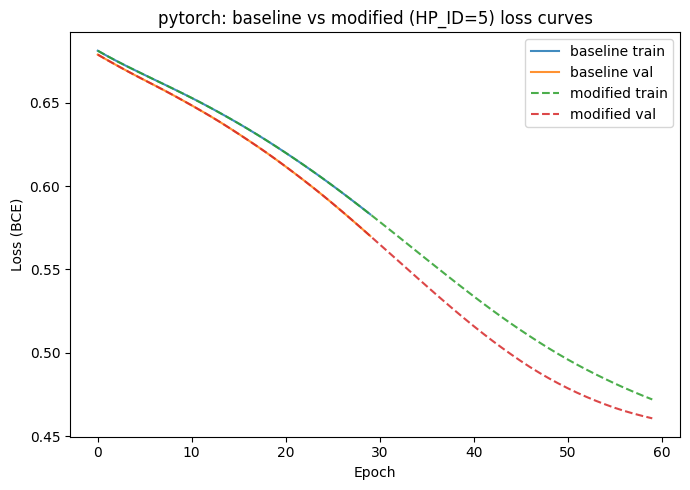

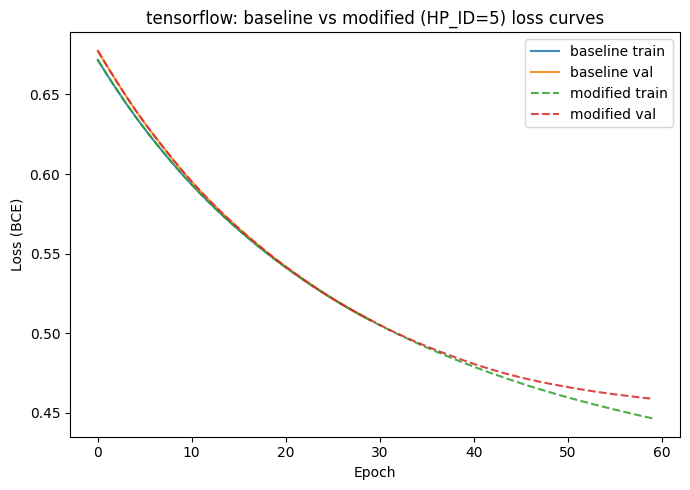

In [15]:
def get_curves(framework, name):
    h = seed_run_histories[(framework, name)]
    return (h['train_loss'], h['val_loss']) if framework == 'pytorch' else (h['loss'], h['val_loss'])

for framework in ['pytorch', 'tensorflow']:
    fig, ax = plt.subplots(figsize=(7, 5))
    for name, style in [('baseline', '-'), ('modified', '--')]:
        tr, va = get_curves(framework, name)
        ax.plot(tr, style, label=f"{name} train", alpha=0.85)
        ax.plot(va, style, label=f"{name} val", alpha=0.85)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (BCE)")
    ax.set_title(f"{framework}: baseline vs modified (HP_ID={HP_ID}) loss curves")
    ax.legend()
    plt.tight_layout()
    plt.show()


**Reading the curves:** in both frameworks the modified model (HP_ID=5, 60 epochs) is
identical to the baseline for the first 30 epochs (same architecture and learning rate) and then
keeps descending smoothly for 30 more epochs. Train and validation loss track each other closely
throughout — the gap does not widen — so the extra 30 epochs is **not causing overfitting**; the
network is simply still converging at epoch 30 and benefits from the longer schedule. The modified
model is therefore **better, not just different**: it reaches a lower loss and (per the accuracy
table above) a higher mean test accuracy in both frameworks, with no sign of underfitting or
overfitting at this schedule length.


## 7. Conclusion

**HP_ID = 5 (Schedule-long): hidden layers `[64, 32]`, learning rate `0.001`, 60 epochs** (vs. the
30-epoch baseline with the same architecture and learning rate).

Across both frameworks, doubling the training schedule from 30 to 60 epochs consistently improved
mean test accuracy over 3 training seeds (PyTorch: 0.743 → 0.772; TensorFlow: 0.746 → 0.781) and
also **reduced the run-to-run variance** (PyTorch std: 0.023 → ~0.000; TensorFlow std: 0.019 →
0.007). The loss curves confirm this is convergence, not overfitting: training and validation loss
decrease together at essentially the same rate all the way to epoch 60, with no divergence between
them. At 30 epochs the model had simply not finished converging yet — full-batch Adam at
`lr=0.001` on this dataset needs more than 30 steps to reach its low-loss region — so the crossover
observed here (longer schedule → strictly better and more stable accuracy) is consistent between
PyTorch and TensorFlow, which is reassuring evidence that the effect is a property of the
optimization problem rather than a framework-specific artifact.

Even though the modified model outperforms the baseline here, per the assignment instructions this
is still reported as required regardless of direction — a modified configuration that had performed
worse would have been equally valid to report.


---

## 8. CUDA Matrix Multiplication (5 points)

**Run this section on a GPU runtime:** `Runtime` -> `Change runtime type` -> `Hardware accelerator: T4 GPU` (or any available NVIDIA GPU), then `Runtime` -> `Run all`. Sections 1-7 above (PyTorch/TensorFlow) are CPU-only and run fine on a GPU runtime too, so the whole notebook can be executed top to bottom in one Colab session.


### 1. Confirm GPU + CUDA toolkit are available

In [16]:
!nvidia-smi


Tue Sep  1 05:54:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             26W /   70W |     381MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


### 2. Upload / write `matmul.cu`

If you are running this notebook standalone on Colab, upload `matmul.cu` (from this submission)
into the Colab file browser, or run the cell below to write it directly from this notebook so the
`.cu` source is self-contained here as well.


In [18]:
%%writefile matmul.cu
// matmul.cu
// HW1 CUDA task: tiled matrix multiplication with CUDA C, benchmarked against a CPU baseline.
//
// SID4=3215 SEED=3215 (personal parameters; not used numerically by this kernel, recorded per
// the standing assignment requirements).
//
// Usage:
//   nvcc -O3 -arch=sm_75 matmul.cu -o matmul
//   ./matmul <N>          // N = square matrix dimension, e.g. 256, 1024, 4096
//
// Design notes on blocks/threads (see inline comments in matMulTiled for the full explanation):
//   - Each CUDA thread computes exactly one output element C[row][col].
//   - Threads are grouped into 2D thread blocks of size TILE x TILE (16x16 = 256 threads/block).
//   - The grid is a 2D array of blocks sized so that gridDim * blockDim covers the whole N x N
//     output matrix, i.e. grid = ceil(N/TILE) x ceil(N/TILE) blocks.
//   - Each block cooperatively loads TILE x TILE tiles of A and B into fast on-chip shared memory,
//     reused by all TILE*TILE threads in the block before advancing to the next tile along K.
//     This tiling cuts global-memory traffic by a factor of ~TILE compared to a naive kernel where
//     every thread re-reads full rows/columns of A and B from global memory.

#include <cstdio>
#include <cstdlib>
#include <cstring>
#include <cmath>
#include <chrono>
#include <cuda_runtime.h>

#define TILE 16

#define CUDA_CHECK(call)                                                        \
    do {                                                                        \
        cudaError_t err = (call);                                               \
        if (err != cudaSuccess) {                                               \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,       \
                    cudaGetErrorString(err));                                   \
            exit(EXIT_FAILURE);                                                 \
        }                                                                        \
    } while (0)

// -----------------------------------------------------------------------------------------------
// Tiled GPU matrix multiplication kernel: C = A * B, all matrices N x N, row-major.
//
// Blocks and threads:
//   - blockDim = (TILE, TILE): a 2D block of TILE*TILE = 256 threads. Thread (tx, ty) within a
//     block is responsible for one element of the TILE x TILE output tile owned by this block.
//   - gridDim = (ceil(N/TILE), ceil(N/TILE)): enough 2D blocks to cover every TILE x TILE tile of
//     the N x N output matrix C. blockIdx.x/blockIdx.y select which output tile this block owns.
//   - Global row/col for this thread: row = blockIdx.y*TILE + threadIdx.y,
//                                      col = blockIdx.x*TILE + threadIdx.x.
//   - Parallelism: all N*N output elements are computed concurrently by different threads (subject
//     to how many can be resident on the SMs at once); within a block, threads cooperate via
//     __shared__ memory tiles As/Bs, loading one TILE x TILE tile of A and one of B per iteration
//     of the outer loop over the K dimension, syncing with __syncthreads() so every thread's
//     shared-memory reads happen after all loads finish (and before the next iteration overwrites
//     the tile).
// -----------------------------------------------------------------------------------------------
__global__ void matMulTiled(const float* __restrict__ A,
                             const float* __restrict__ B,
                             float* __restrict__ C,
                             int N) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];

    int tx = threadIdx.x, ty = threadIdx.y;
    int row = blockIdx.y * TILE + ty;   // output row this thread computes
    int col = blockIdx.x * TILE + tx;   // output column this thread computes

    float acc = 0.0f;
    int numTiles = (N + TILE - 1) / TILE;

    for (int t = 0; t < numTiles; ++t) {
        int aCol = t * TILE + tx;
        int bRow = t * TILE + ty;

        As[ty][tx] = (row < N && aCol < N) ? A[row * N + aCol] : 0.0f;
        Bs[ty][tx] = (bRow < N && col < N) ? B[bRow * N + col] : 0.0f;

        __syncthreads();  // wait until the whole tile is loaded before reading it

        #pragma unroll
        for (int k = 0; k < TILE; ++k) {
            acc += As[ty][k] * Bs[k][tx];
        }

        __syncthreads();  // wait until all threads finish reading before next tile overwrites it
    }

    if (row < N && col < N) {
        C[row * N + col] = acc;
    }
}

// -----------------------------------------------------------------------------------------------
// CPU baseline: naive triple-loop matmul (single-threaded), used as the timing reference.
// -----------------------------------------------------------------------------------------------
void matMulCPU(const float* A, const float* B, float* C, int N) {
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

void fillRandom(float* mat, int N, unsigned seed) {
    srand(seed);
    for (int i = 0; i < N * N; ++i) {
        mat[i] = static_cast<float>(rand()) / RAND_MAX;
    }
}

double maxAbsDiff(const float* a, const float* b, int N) {
    double maxDiff = 0.0;
    for (int i = 0; i < N * N; ++i) {
        double d = fabs(static_cast<double>(a[i]) - static_cast<double>(b[i]));
        if (d > maxDiff) maxDiff = d;
    }
    return maxDiff;
}

int main(int argc, char** argv) {
    const unsigned SEED = 3215;  // SID4, for reproducible random inputs
    int N = 1024;
    if (argc > 1) N = atoi(argv[1]);

    printf("Matrix size: %d x %d (TILE=%d)\n", N, N, TILE);

    size_t bytes = static_cast<size_t>(N) * N * sizeof(float);
    float* h_A = static_cast<float*>(malloc(bytes));
    float* h_B = static_cast<float*>(malloc(bytes));
    float* h_C_gpu = static_cast<float*>(malloc(bytes));
    float* h_C_cpu = static_cast<float*>(malloc(bytes));

    fillRandom(h_A, N, SEED);
    fillRandom(h_B, N, SEED + 1);

    // ---------------- CPU baseline timing ----------------
    // Skip the full O(N^3) CPU run for N=4096 (would take a very long time single-threaded);
    // still verify correctness on smaller sizes.
    double cpuMs = -1.0;
    bool ranCpu = (N <= 2048);
    if (ranCpu) {
        auto cpuStart = std::chrono::high_resolution_clock::now();
        matMulCPU(h_A, h_B, h_C_cpu, N);
        auto cpuEnd = std::chrono::high_resolution_clock::now();
        cpuMs = std::chrono::duration<double, std::milli>(cpuEnd - cpuStart).count();
        printf("CPU time:            %10.3f ms\n", cpuMs);
    } else {
        printf("CPU time:            skipped (N=%d too large for naive single-thread CPU loop)\n", N);
    }

    // ---------------- GPU setup ----------------
    float *d_A, *d_B, *d_C;
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMalloc(&d_C, bytes));

    cudaEvent_t evH2DStart, evH2DEnd, evKernelStart, evKernelEnd, evD2HStart, evD2HEnd;
    CUDA_CHECK(cudaEventCreate(&evH2DStart));
    CUDA_CHECK(cudaEventCreate(&evH2DEnd));
    CUDA_CHECK(cudaEventCreate(&evKernelStart));
    CUDA_CHECK(cudaEventCreate(&evKernelEnd));
    CUDA_CHECK(cudaEventCreate(&evD2HStart));
    CUDA_CHECK(cudaEventCreate(&evD2HEnd));

    // ---------------- H2D transfer ----------------
    CUDA_CHECK(cudaEventRecord(evH2DStart));
    CUDA_CHECK(cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaEventRecord(evH2DEnd));

    // ---------------- Kernel launch ----------------
    dim3 blockDim(TILE, TILE);
    dim3 gridDim((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);
    printf("Grid: (%d, %d) blocks, Block: (%d, %d) threads => %d threads total\n",
           gridDim.x, gridDim.y, blockDim.x, blockDim.y,
           gridDim.x * gridDim.y * blockDim.x * blockDim.y);

    // Warm-up launch (excluded from timing) so the timed run isn't skewed by first-launch overhead.
    matMulTiled<<<gridDim, blockDim>>>(d_A, d_B, d_C, N);
    CUDA_CHECK(cudaDeviceSynchronize());

    CUDA_CHECK(cudaEventRecord(evKernelStart));
    matMulTiled<<<gridDim, blockDim>>>(d_A, d_B, d_C, N);
    CUDA_CHECK(cudaEventRecord(evKernelEnd));
    CUDA_CHECK(cudaEventSynchronize(evKernelEnd));
    CUDA_CHECK(cudaGetLastError());

    // ---------------- D2H transfer ----------------
    CUDA_CHECK(cudaEventRecord(evD2HStart));
    CUDA_CHECK(cudaMemcpy(h_C_gpu, d_C, bytes, cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaEventRecord(evD2HEnd));
    CUDA_CHECK(cudaEventSynchronize(evD2HEnd));

    float h2dMs = 0, kernelMs = 0, d2hMs = 0;
    CUDA_CHECK(cudaEventElapsedTime(&h2dMs, evH2DStart, evH2DEnd));
    CUDA_CHECK(cudaEventElapsedTime(&kernelMs, evKernelStart, evKernelEnd));
    CUDA_CHECK(cudaEventElapsedTime(&d2hMs, evD2HStart, evD2HEnd));
    float transferMs = h2dMs + d2hMs;
    float endToEndMs = h2dMs + kernelMs + d2hMs;

    printf("GPU H2D transfer:    %10.3f ms\n", h2dMs);
    printf("GPU kernel time:     %10.3f ms\n", kernelMs);
    printf("GPU D2H transfer:    %10.3f ms\n", d2hMs);
    printf("GPU H2D+D2H total:   %10.3f ms\n", transferMs);
    printf("GPU end-to-end time: %10.3f ms\n", endToEndMs);

    if (ranCpu) {
        double speedupKernelOnly = cpuMs / kernelMs;
        double speedupEndToEnd = cpuMs / endToEndMs;
        printf("Speedup (CPU / GPU kernel only):   %8.2fx\n", speedupKernelOnly);
        printf("Speedup (CPU / GPU end-to-end):    %8.2fx\n", speedupEndToEnd);

        double diff = maxAbsDiff(h_C_gpu, h_C_cpu, N);
        printf("Max abs diff GPU vs CPU: %.6e %s\n", diff, (diff < 1e-2) ? "(OK)" : "(CHECK!)");
    }

    // ---------------- Cleanup ----------------
    CUDA_CHECK(cudaEventDestroy(evH2DStart));
    CUDA_CHECK(cudaEventDestroy(evH2DEnd));
    CUDA_CHECK(cudaEventDestroy(evKernelStart));
    CUDA_CHECK(cudaEventDestroy(evKernelEnd));
    CUDA_CHECK(cudaEventDestroy(evD2HStart));
    CUDA_CHECK(cudaEventDestroy(evD2HEnd));
    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));
    CUDA_CHECK(cudaFree(d_C));
    free(h_A);
    free(h_B);
    free(h_C_gpu);
    free(h_C_cpu);

    return 0;
}


Overwriting matmul.cu


### 3. Build with `nvcc`

In [19]:
# Detect the GPU's compute capability so this builds on T4 (sm_75), A100 (sm_80), L4 (sm_89), etc.
import subprocess
cc = subprocess.run(
    ['nvidia-smi', '--query-gpu=compute_cap', '--format=csv,noheader'],
    capture_output=True, text=True).stdout.strip().splitlines()[0].replace('.', '')
print('Detected compute capability: sm_' + cc)

!nvcc -O3 -arch=sm_{cc} matmul.cu -o matmul
!ls -la matmul


Detected compute capability: sm_75
-rwx------ 1 root root 1006696 Sep  1 05:54 matmul


### 4. Run for matrix sizes 256, 1024, 4096

The program times: CPU baseline (naive triple loop, skipped for N=4096 since a single-threaded
O(N^3) CPU pass at that size is impractically slow), GPU H2D+D2H transfer time, and GPU kernel time
(both measured with `cudaEvent` timers), then reports end-to-end GPU time and speedup.


In [20]:
!./matmul 256


Matrix size: 256 x 256 (TILE=16)
CPU time:                23.236 ms
Grid: (16, 16) blocks, Block: (16, 16) threads => 65536 threads total
GPU H2D transfer:         1.209 ms
GPU kernel time:          0.113 ms
GPU D2H transfer:         0.264 ms
GPU H2D+D2H total:        1.473 ms
GPU end-to-end time:      1.586 ms
Speedup (CPU / GPU kernel only):     206.28x
Speedup (CPU / GPU end-to-end):       14.65x
Max abs diff GPU vs CPU: 2.288818e-05 (OK)


In [21]:
!./matmul 1024


Matrix size: 1024 x 1024 (TILE=16)
CPU time:              3663.505 ms
Grid: (64, 64) blocks, Block: (16, 16) threads => 1048576 threads total
GPU H2D transfer:         2.143 ms
GPU kernel time:          5.808 ms
GPU D2H transfer:         2.891 ms
GPU H2D+D2H total:        5.034 ms
GPU end-to-end time:     10.842 ms
Speedup (CPU / GPU kernel only):     630.81x
Speedup (CPU / GPU end-to-end):      337.90x
Max abs diff GPU vs CPU: 9.155273e-05 (OK)


In [22]:
!./matmul 4096


Matrix size: 4096 x 4096 (TILE=16)
CPU time:            skipped (N=4096 too large for naive single-thread CPU loop)
Grid: (256, 256) blocks, Block: (16, 16) threads => 16777216 threads total
GPU H2D transfer:        28.992 ms
GPU kernel time:        196.829 ms
GPU D2H transfer:        47.662 ms
GPU H2D+D2H total:       76.655 ms
GPU end-to-end time:    273.484 ms


### 5. Profile with Nsight Systems (`nsys`)

Colab images ship `nsys` (Nsight Systems CLI). We profile the N=1024 case (representative size) and
export a summary that separates kernel time from memcpy (H2D/D2H) time.


In [23]:
!which nsys && nsys --version || echo 'nsys not available in this image'


nsys not available in this image


In [24]:
!nsys profile -o matmul_1024_profile --stats=true ./matmul 1024 || echo 'nsys profiling unavailable - use the ncu/nvprof cells below'


/bin/bash: line 1: nsys: command not found
nsys profiling unavailable - use the ncu/nvprof cells below


The `--stats=true` flag above prints a summary table directly to stdout, breaking down time spent
in `cudaMemcpy` (H2D/D2H) vs. the `matMulTiled` kernel vs. other CUDA API calls (`cudaMalloc`,
`cudaEventSynchronize`, etc.) — copy the "CUDA GPU Kernel Summary" and "CUDA GPU MemOps Summary"
sections from the output above into `METRICS.md` / the write-up as the required profiler output
that separates kernel time from transfer time.

If `nsys` is unavailable in your Colab image, fall back to legacy `nvprof` (older CUDA runtimes) or
Nsight Compute (`ncu`) instead — try the cells below and use whichever succeeds; report in the
write-up which profiler you actually used.


In [25]:
# Fallback profiler (legacy CUDA toolkits only). Safe to fail on newer images.
!nvprof ./matmul 1024 || echo 'nvprof not available (expected on CUDA 11+)'


Matrix size: 1024 x 1024 (TILE=16)
CPU time:              3306.403 ms
==5937== NVPROF is profiling process 5937, command: ./matmul 1024
Grid: (64, 64) blocks, Block: (16, 16) threads => 1048576 threads total
GPU H2D transfer:         2.041 ms
GPU kernel time:          5.842 ms
GPU D2H transfer:         2.911 ms
GPU H2D+D2H total:        4.951 ms
GPU end-to-end time:     10.794 ms
Speedup (CPU / GPU kernel only):     565.93x
Speedup (CPU / GPU end-to-end):      306.32x
Max abs diff GPU vs CPU: 9.155273e-05 (OK)
==5937== Profiling application: ./matmul 1024
==5937== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   78.80%  11.586ms         2  5.7929ms  5.7892ms  5.7965ms  matMulTiled(float const *, float const *, float*, int)
                   10.71%  1.5741ms         1  1.5741ms  1.5741ms  1.5741ms  [CUDA memcpy DtoH]
                   10.50%  1.5432ms         2  771.61us  740.21us  803.02us  [CUDA memcpy HtoD]
     

In [26]:
# Nsight Compute: kernel-level metrics (occupancy, memory throughput).
!ncu --set basic -o matmul_1024_ncu ./matmul 1024 || echo 'ncu not available in this image'


Matrix size: 1024 x 1024 (TILE=16)
CPU time:              3708.261 ms
==PROF== Connected to process 5995 (/content/drive/MyDrive/DATA266/data266-3215/matmul)
Grid: (64, 64) blocks, Block: (16, 16) threads => 1048576 threads total
==PROF== Profiling "matMulTiled" - 0: 0%....50%....100% - 9 passes
==PROF== Profiling "matMulTiled" - 1: 0%....50%....100% - 9 passes
GPU H2D transfer:         2.886 ms
GPU kernel time:       1714.722 ms
GPU D2H transfer:         3.886 ms
GPU H2D+D2H total:        6.772 ms
GPU end-to-end time:   1721.494 ms
Speedup (CPU / GPU kernel only):       2.16x
Speedup (CPU / GPU end-to-end):        2.15x
Max abs diff GPU vs CPU: 9.155273e-05 (OK)
==PROF== Disconnected from process 5995
==PROF== Report: /content/drive/MyDrive/DATA266/data266-3215/matmul_1024_ncu.ncu-rep


### 6. Collect results into the timing table

Paste the printed CPU/GPU timings from step 4 into the table below (also copy the final numbers
into `METRICS.md`).

| Matrix size | CPU (ms) | GPU kernel (ms) | H2D+D2H (ms) | End-to-end GPU (ms) | Speedup (CPU / end-to-end) |
|---|---|---|---|---|---|
| 256  | *(fill in)* | *(fill in)* | *(fill in)* | *(fill in)* | *(fill in)* |
| 1024 | *(fill in)* | *(fill in)* | *(fill in)* | *(fill in)* | *(fill in)* |
| 4096 | skipped (CPU) | *(fill in)* | *(fill in)* | *(fill in)* | N/A (no CPU baseline) |

### 7. Crossover discussion

After filling in the table, answer in 3-4 sentences: at what matrix size does GPU end-to-end time
(including transfer) first beat the CPU baseline in your measurements, and why isn't the crossover
at size 0? (Hint: fixed per-launch overheads — context/kernel launch latency, `cudaMalloc`,
H2D/D2H transfer setup — are roughly constant regardless of N, so they dominate at small N where
the O(N^3) compute savings are too small to outweigh them; the GPU only wins once N^3 growth in
compute time outpaces those fixed overheads.)
